**Data Science Project - Stock Market Analysis and Predictions**

In [1]:
import pandas as pd
from pandas import DataFrame,Series
from datetime import datetime
import future
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
# Importing the data for the tech stocks of Tesla, AMD, Nvidia, Apple, Google, Microsoft and Amazon for the last 3 years
tech_list = ['TSLA','AMD','NVDA','AAPL','GOOG','MSFT','AMZN']
end = datetime.now()
start = datetime(end.year-3,end.month,end.day)

In [3]:
for stock in tech_list:
    globals()[stock] = yf.download(stock, start=start, end=end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
for stock in tech_list:
    print(f"{stock}: {globals()[stock].shape}")
    print(globals()[stock].head())

TSLA: (752, 5)
Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2023-04-13  185.899994  186.500000  180.940002  182.960007  112933000
2023-04-14  185.000000  186.279999  182.009995  183.949997   96438700
2023-04-17  187.039993  189.690002  182.690002  186.320007  116662200
2023-04-18  184.309998  187.690002  183.580002  187.149994   92067000
2023-04-19  180.589996  183.500000  177.649994  179.100006  125732700
AMD: (752, 5)
Price           Close       High        Low       Open    Volume
Ticker            AMD        AMD        AMD        AMD       AMD
Date                                                            
2023-04-13  92.089996  93.160004  91.830002  92.790001  40572500
2023-04-14  91.750000  92.970001  90.500000  91.820000  38734800
2023-04-17  89.870003  90.690002  88.300003  90.230003  47250800
2023-04-18  89.779999

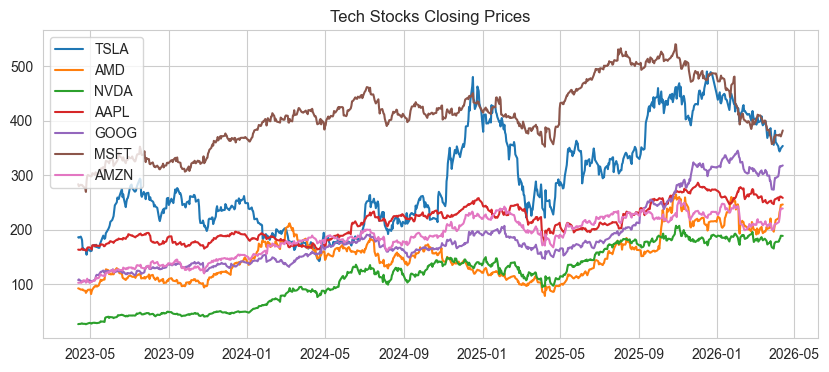

In [5]:
plt.figure(figsize=(10,4))
for stock in tech_list:
    if not globals()[stock].empty:
        plt.plot(globals()[stock].index, globals()[stock]['Close'], label=stock)

plt.legend()
plt.title('Tech Stocks Closing Prices')
plt.show()

In [6]:
ma_day = [5,10,20,50,100]

for ma in ma_day:
    column_name = f"MA for {ma} days"
    AAPL[column_name] = AAPL['Close'].rolling(window=ma).mean()

<Axes: xlabel='Date'>

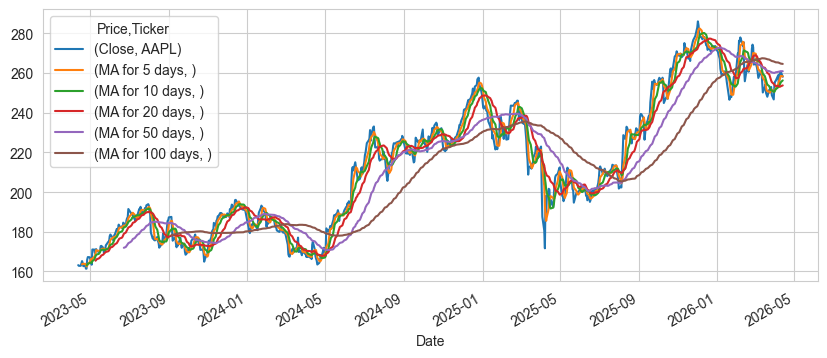

In [7]:
AAPL[['Close'] + [f"MA for {ma} days" for ma in ma_day]].plot(figsize=(10,4))

<Axes: title={'center': 'Daily Return for AAPL'}, xlabel='Date'>

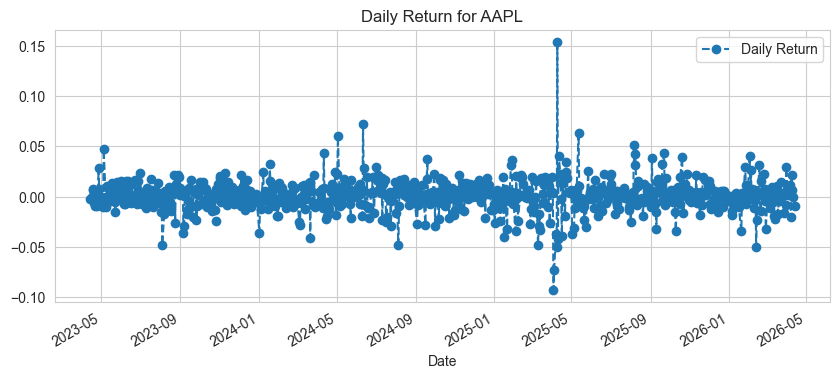

In [8]:
AAPL['Daily Return'] = AAPL['Close'].pct_change()
AAPL['Daily Return'].plot(figsize=(10,4), legend=True, linestyle='--', marker='o', title='Daily Return for AAPL')

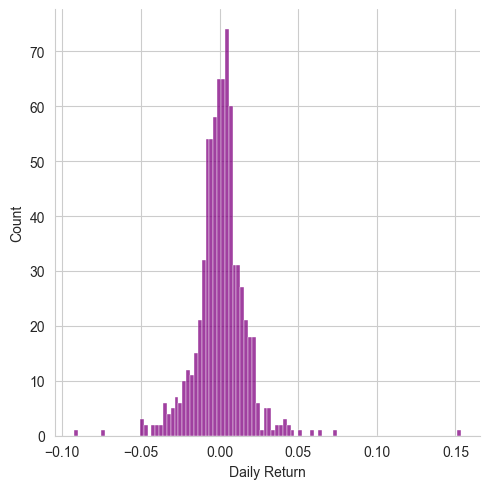

In [9]:
sns.displot(AAPL['Daily Return'].dropna(), bins=100, color='purple')

<Axes: >

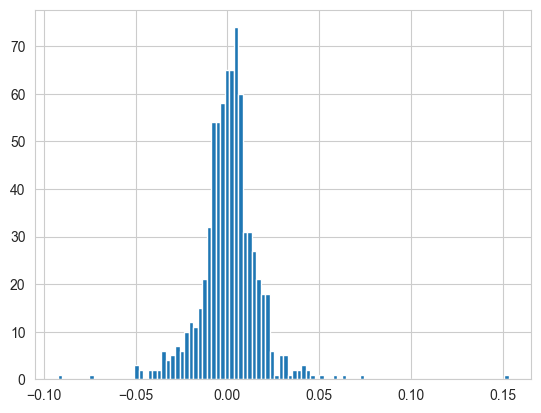

In [10]:
AAPL['Daily Return'].hist(bins=100)

In [11]:
closing_df = yf.download(tech_list, start=start, end=end)['Close']
closing_df.head()

[*********************100%***********************]  7 of 7 completed


Ticker,AAPL,AMD,AMZN,GOOG,MSFT,NVDA,TSLA
Date,,,,,,,
2023-04-13,163.195786,92.089996,102.400002,107.308990,283.134827,26.439598,185.899994
2023-04-14,162.850800,91.750000,102.510002,108.568649,279.520477,26.734333,185.000000
2023-04-17,162.870468,89.870003,102.739998,105.553406,282.118866,26.978119,187.039993
2023-04-18,164.092743,89.779999,102.300003,104.264008,281.698822,27.642529,184.309998
2023-04-19,165.236221,89.940002,104.300003,104.164818,281.777039,27.906296,180.589996


In [12]:
tech_rets = closing_df.pct_change()
tech_rets.head()

Ticker,AAPL,AMD,AMZN,GOOG,MSFT,NVDA,TSLA
Date,,,,,,,
2023-04-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04-14,-0.002114,-0.003692,0.001074,0.011739,-0.012765,0.011147,-0.004841
2023-04-17,0.000121,-0.020490,0.002244,-0.027773,0.009296,0.009119,0.011027
2023-04-18,0.007505,-0.001001,-0.004283,-0.012216,-0.001489,0.024628,-0.014596
2023-04-19,0.006968,0.001782,0.019550,-0.000951,0.000278,0.009542,-0.020183


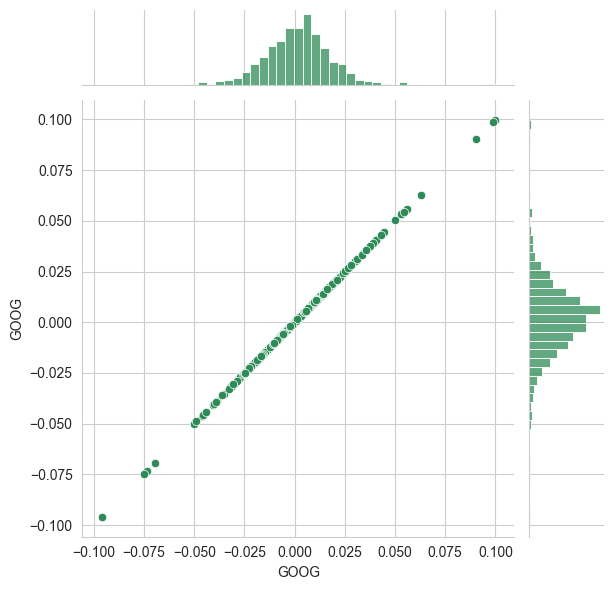

In [13]:
sns.jointplot(x='GOOG', y='GOOG', data=tech_rets, kind='scatter', color='seagreen')

Text(0.05, 0.95, 'Pearson: 0.42')

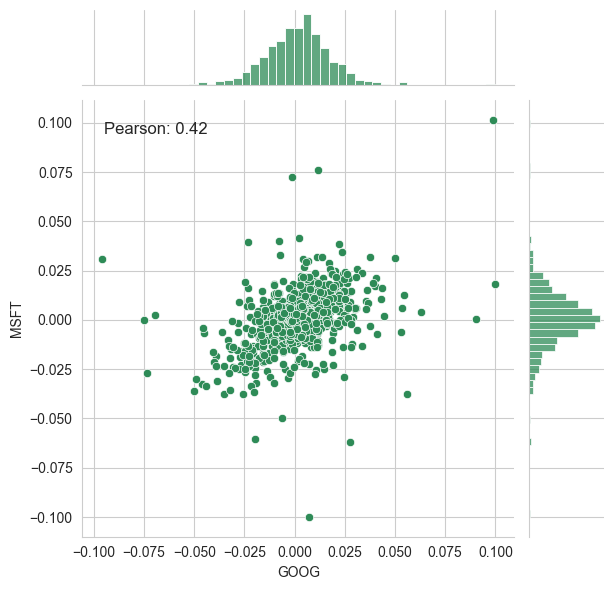

In [14]:
g = sns.jointplot(x='GOOG', y='MSFT', data=tech_rets, kind='scatter', color='seagreen')
corr = tech_rets['GOOG'].corr(tech_rets['MSFT'])
g.ax_joint.text(0.05, 0.95, f'Pearson: {corr:.2f}', transform=g.ax_joint.transAxes, fontsize=12, verticalalignment='top')

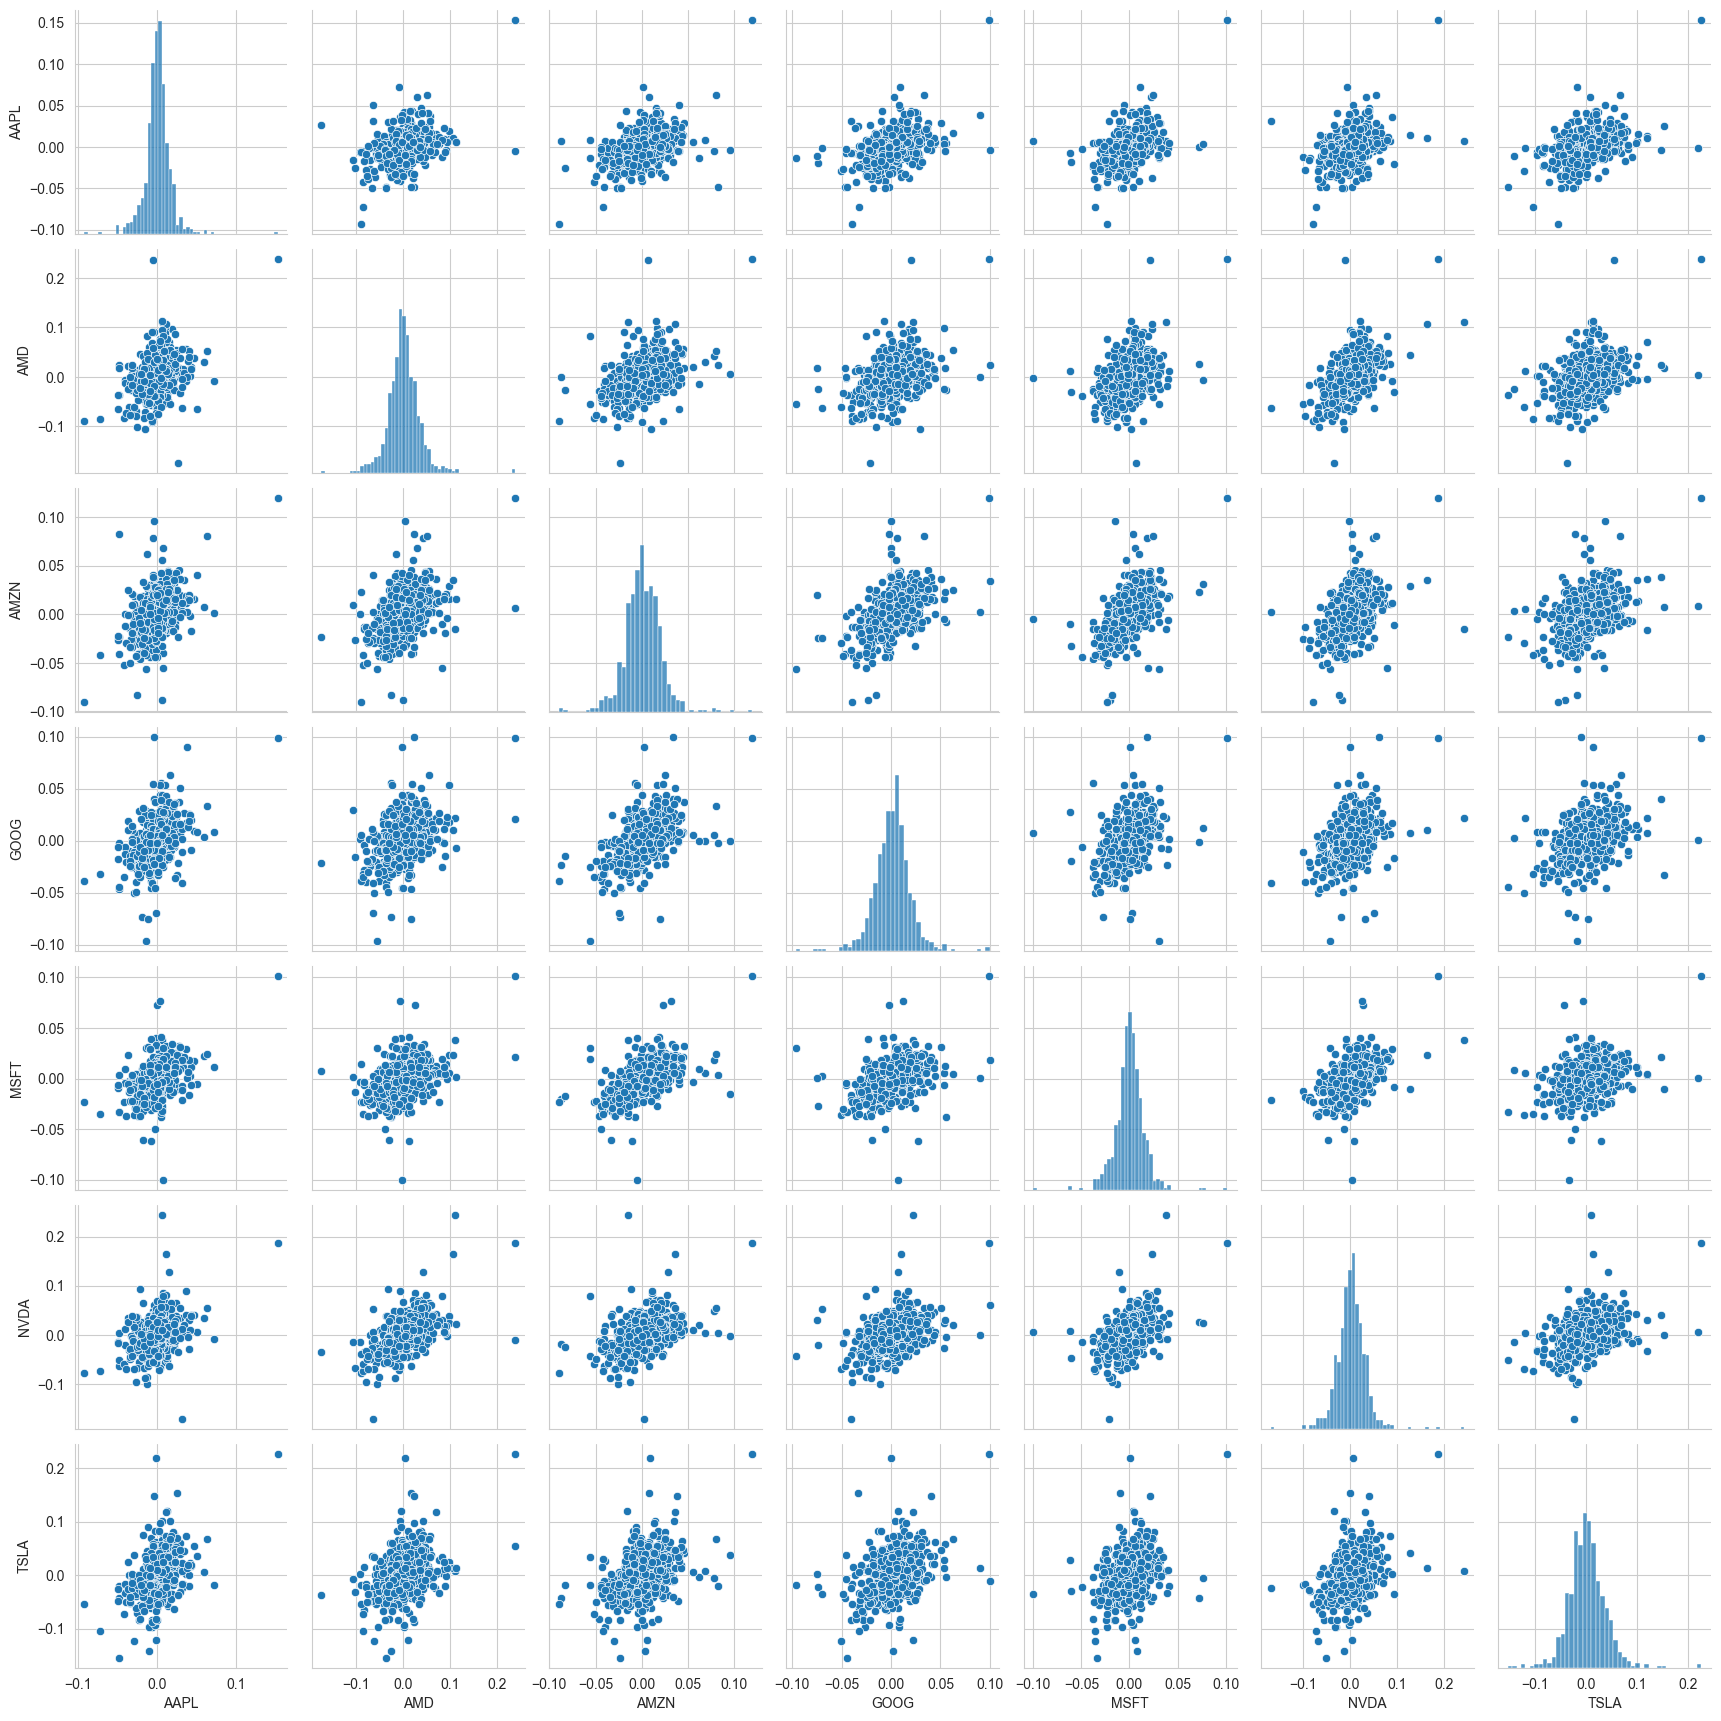

In [15]:
sns.pairplot(tech_rets.dropna())

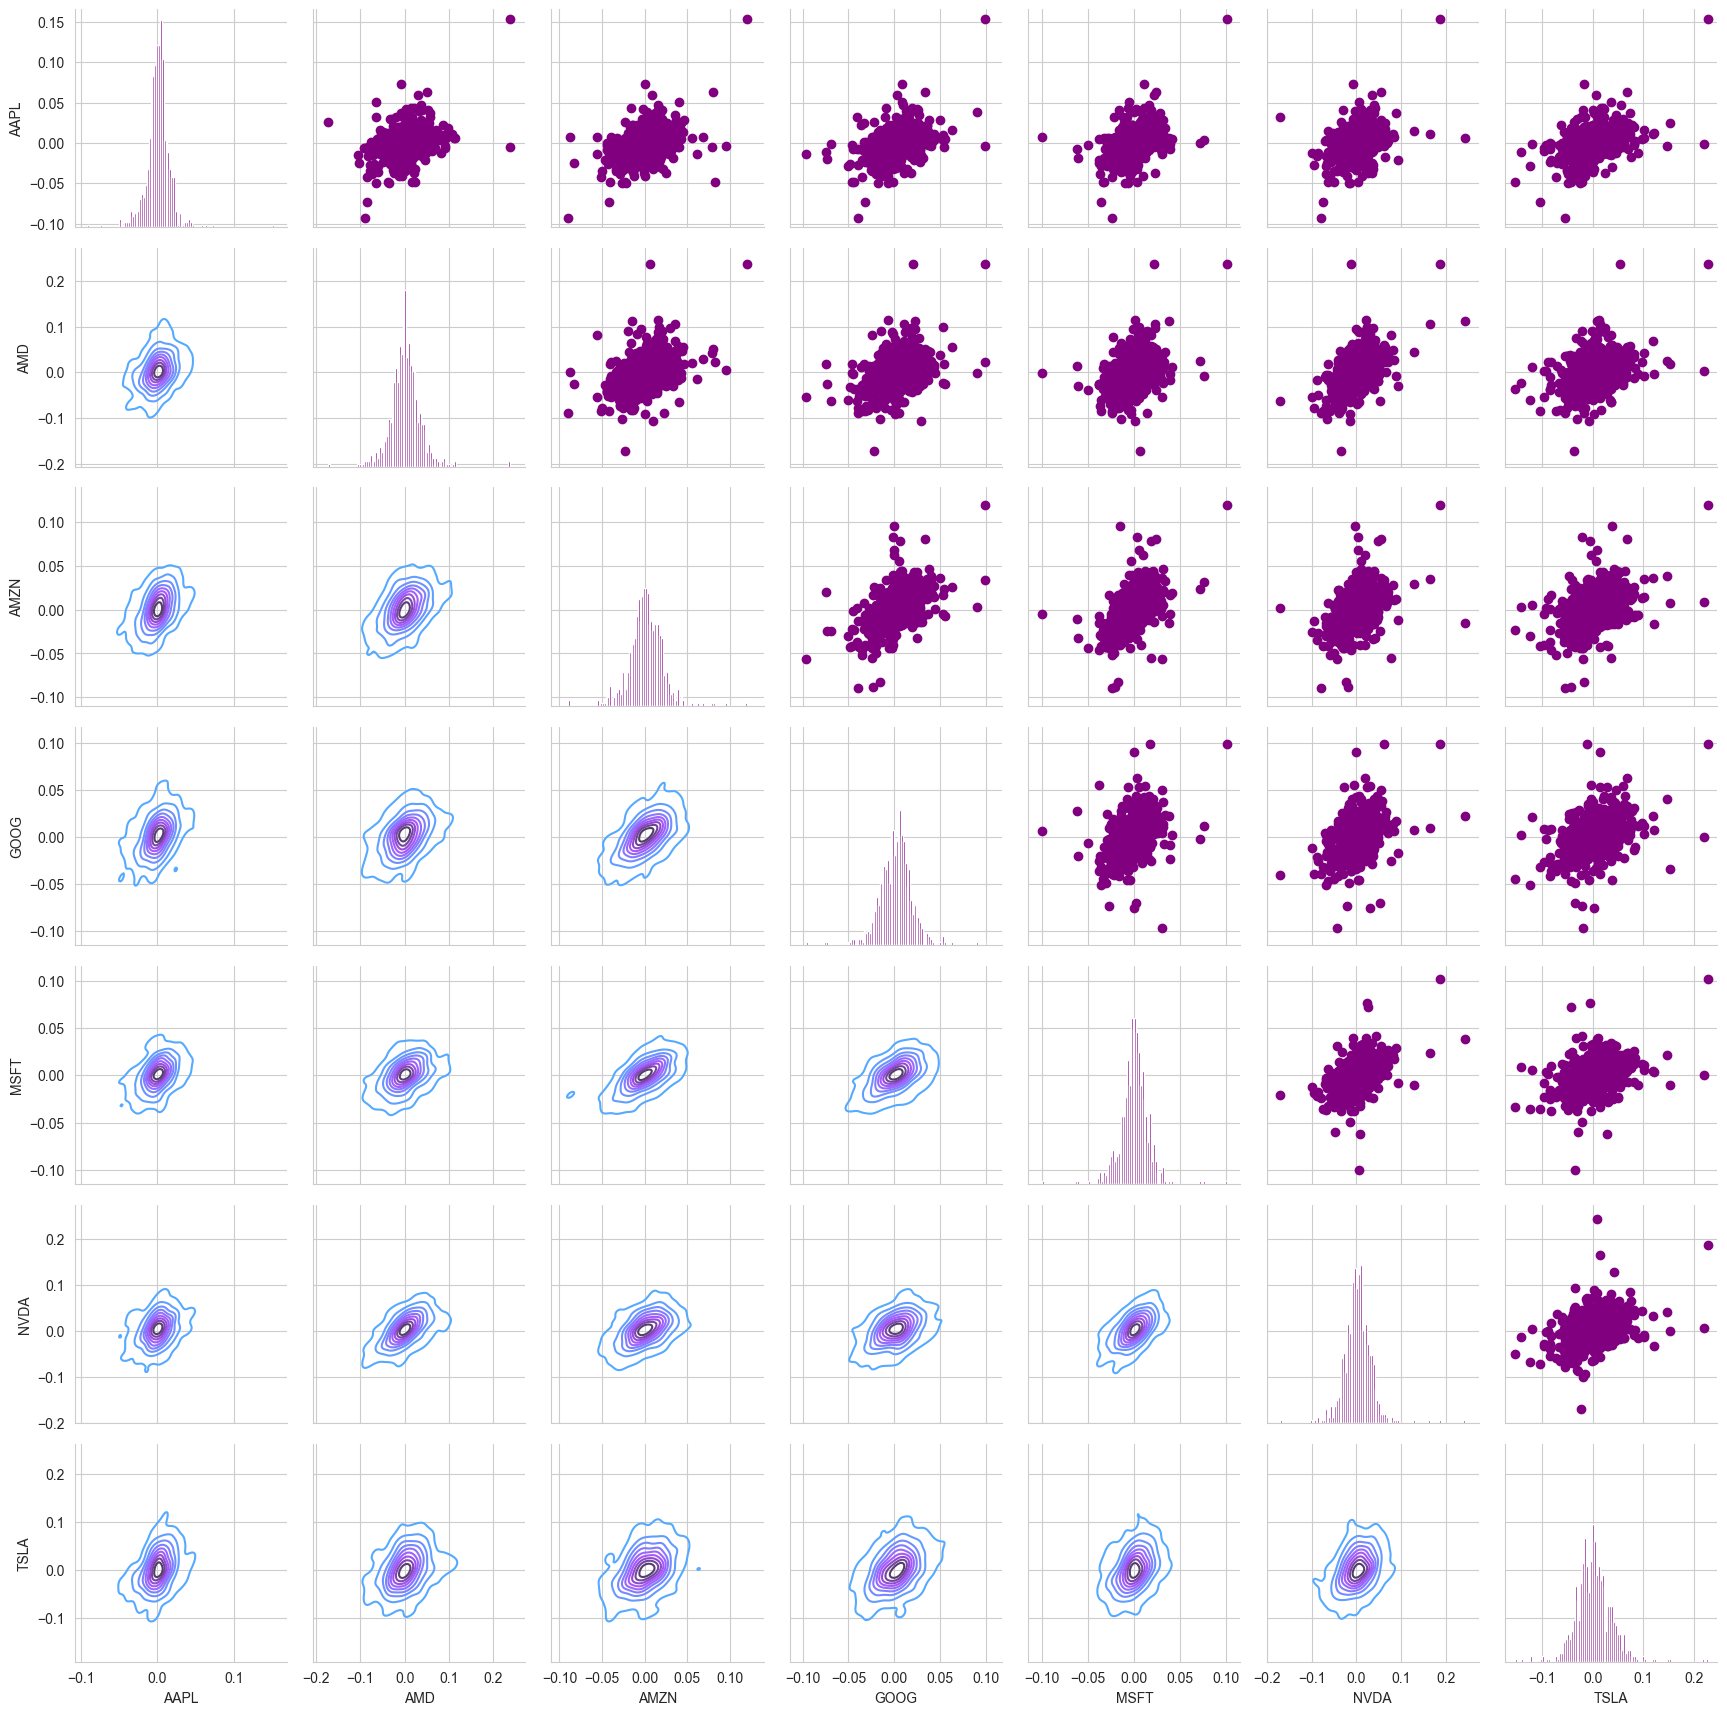

In [16]:
returns_fig = sns.PairGrid(tech_rets.dropna())
returns_fig.map_upper(plt.scatter, color='purple')
returns_fig.map_lower(sns.kdeplot, cmap = 'cool_d')
returns_fig.map_diag(plt.hist, bins=100, color='purple')

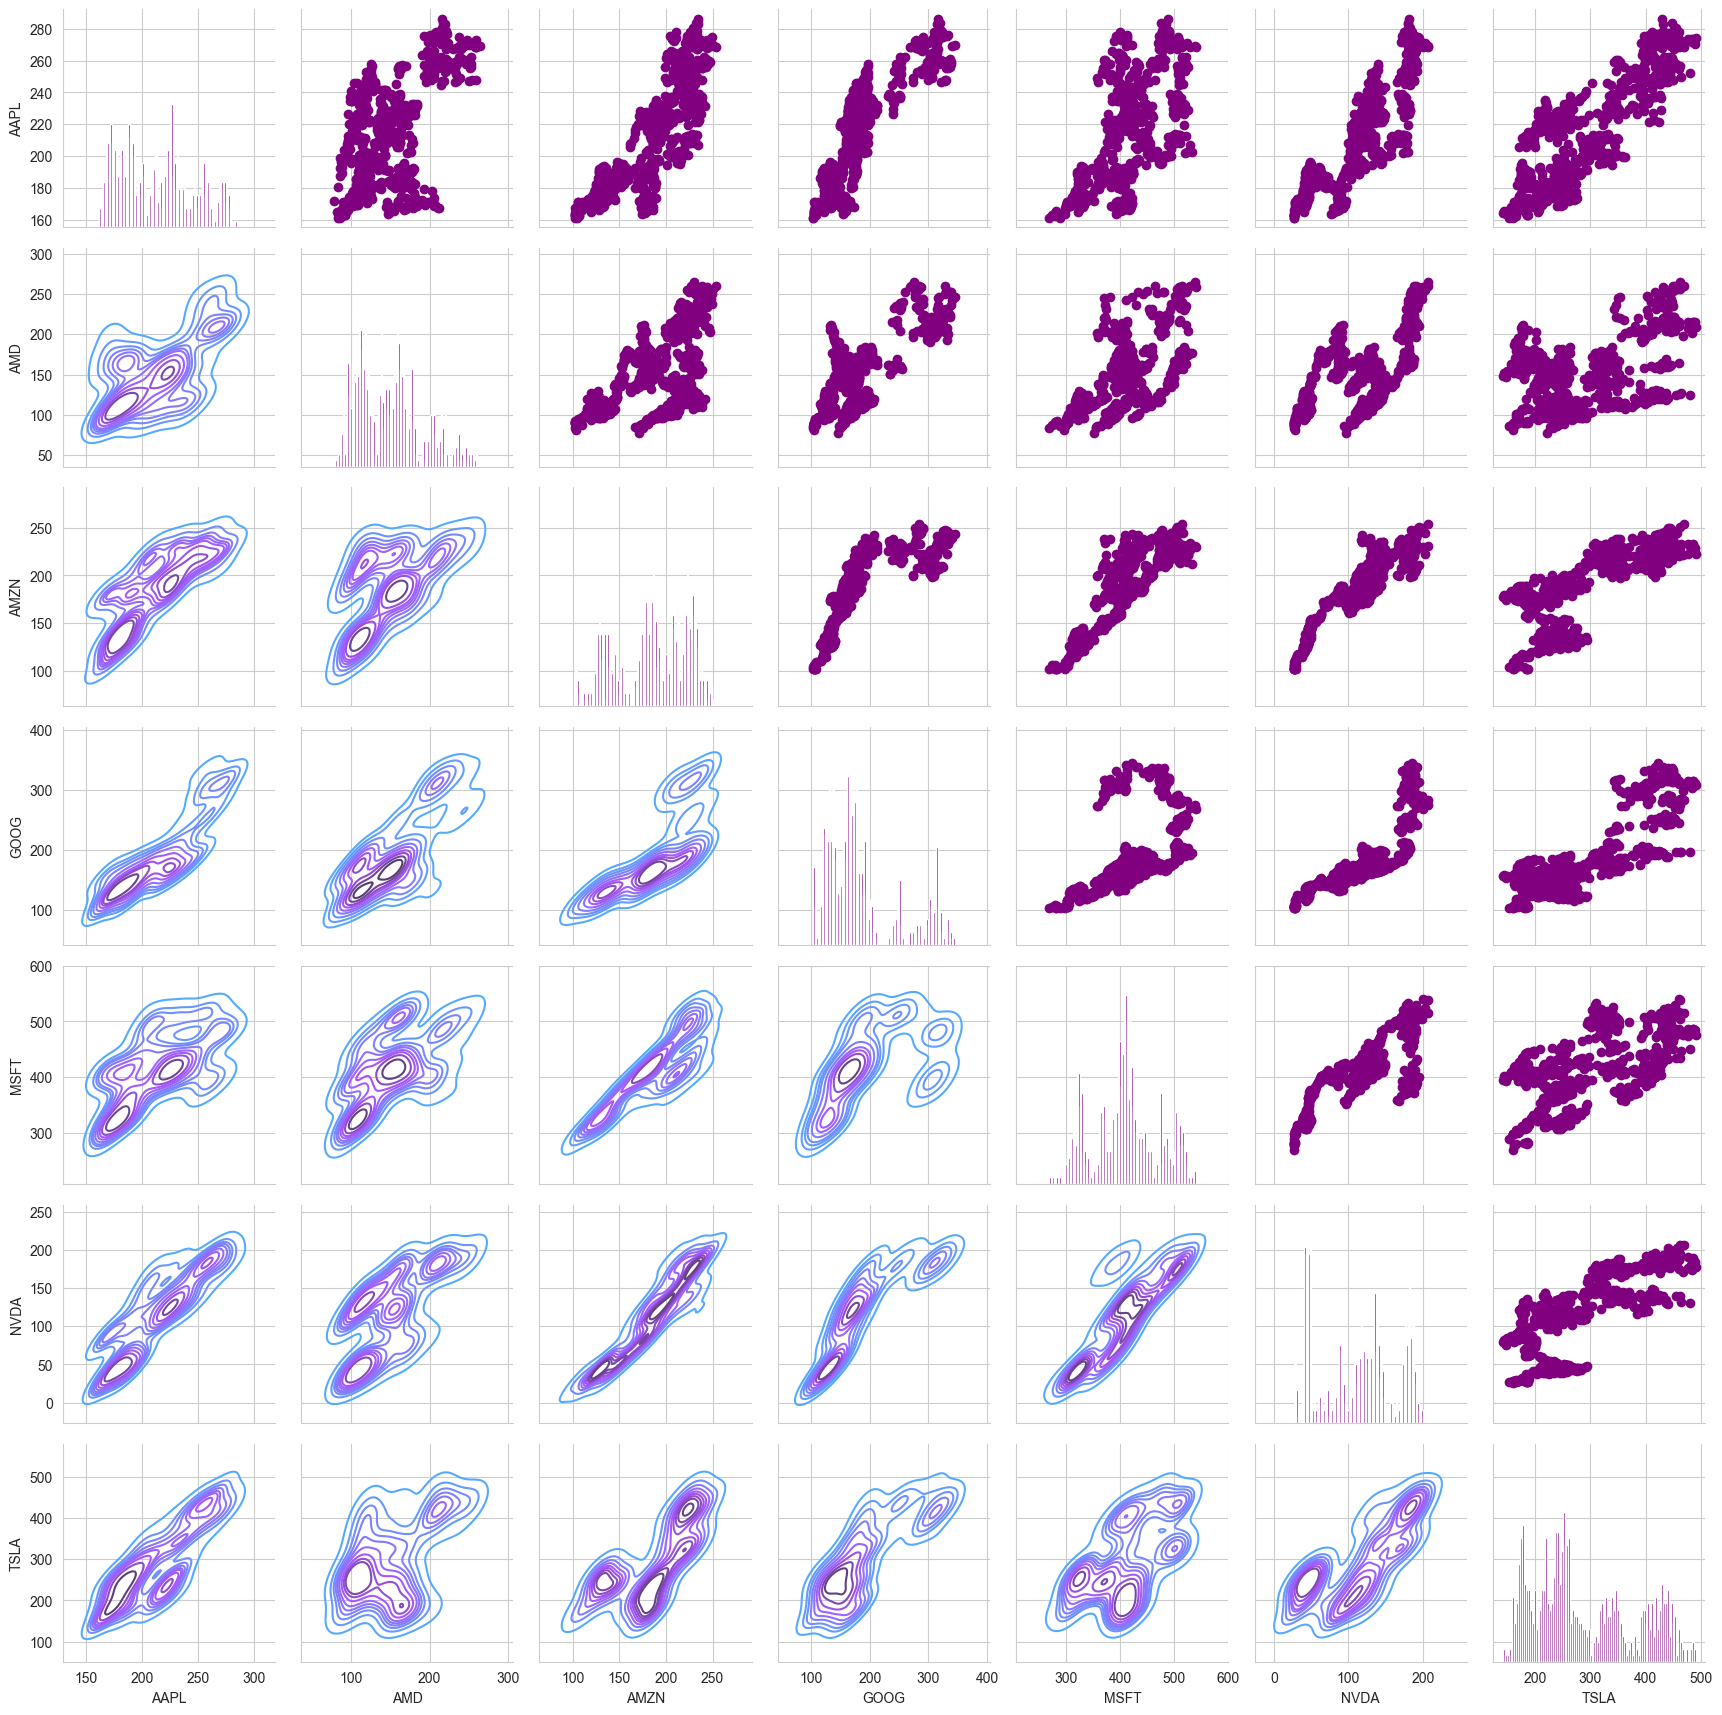

In [17]:
returns_fig = sns.PairGrid(closing_df.dropna())
returns_fig.map_upper(plt.scatter, color='purple')
returns_fig.map_lower(sns.kdeplot, cmap = 'cool_d')
returns_fig.map_diag(plt.hist, bins=100, color='purple')

<Axes: xlabel='Ticker', ylabel='Ticker'>

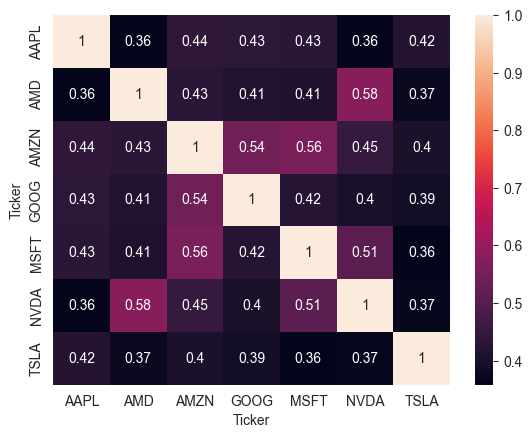

In [18]:
sns.heatmap(tech_rets.dropna().corr(), annot=True)

**Risk Analysis**

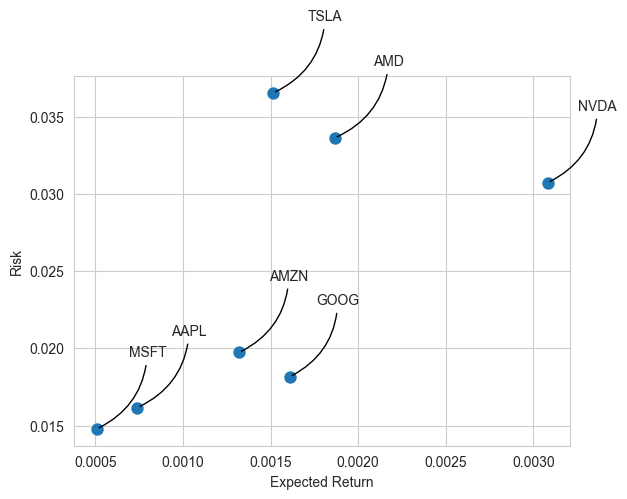

In [19]:
rets = tech_rets.dropna()
area = np.pi*20
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected Return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label,
                 xy= (x,y), xytext=(50,50),
                 textcoords='offset points', ha = 'right', va ='bottom',
                 arrowprops= dict(arrowstyle= '-', connectionstyle = 'arc3,rad= -0.3', color='black'))

**Value at Risk**

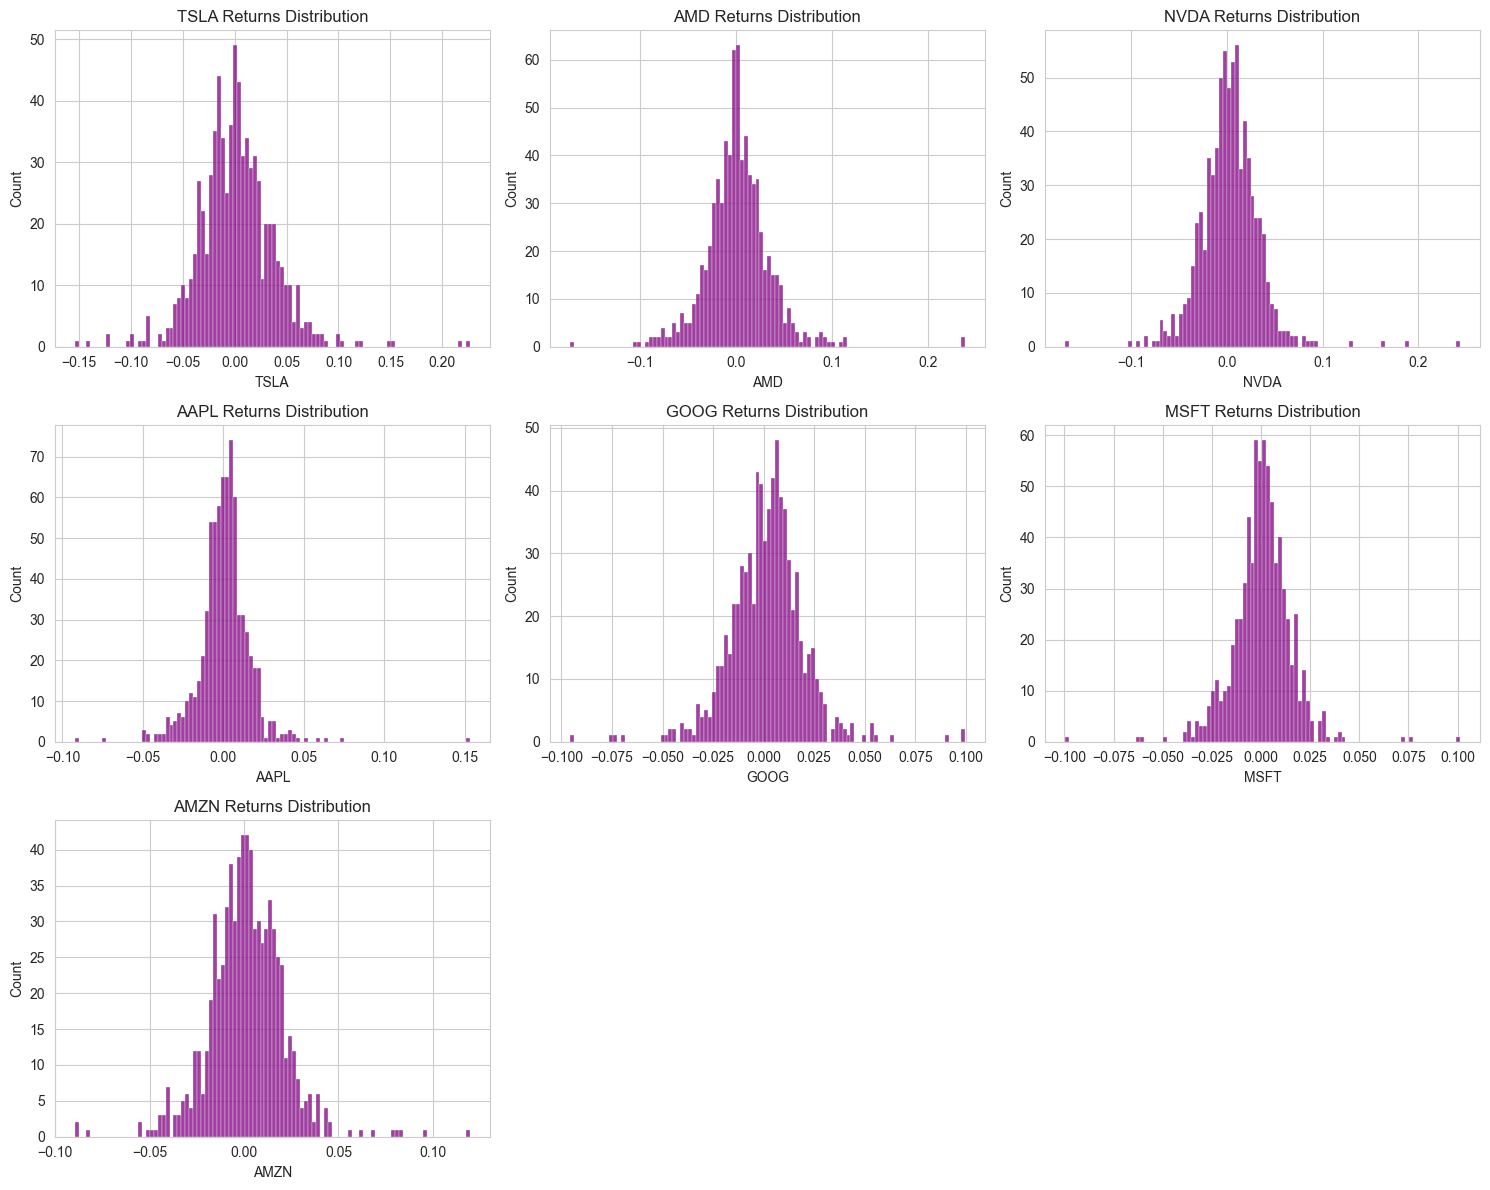

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, stock in enumerate(tech_list):
    sns.histplot(rets[stock].dropna(), bins=100, color='purple', ax=axes[i])
    axes[i].set_title(f'{stock} Returns Distribution')

# Hide the empty subplots
for j in range(len(tech_list), 9):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
rets.head()

Ticker,AAPL,AMD,AMZN,GOOG,MSFT,NVDA,TSLA
Date,,,,,,,
2023-04-14,-0.002114,-0.003692,0.001074,0.011739,-0.012765,0.011147,-0.004841
2023-04-17,0.000121,-0.020490,0.002244,-0.027773,0.009296,0.009119,0.011027
2023-04-18,0.007505,-0.001001,-0.004283,-0.012216,-0.001489,0.024628,-0.014596
2023-04-19,0.006968,0.001782,0.019550,-0.000951,0.000278,0.009542,-0.020183
2023-04-20,-0.005846,0.001890,-0.004698,0.008379,-0.008113,-0.029609,-0.097458


In [22]:
for stock in tech_list:
    print(f"{stock} 5% Quantile: {rets[stock].quantile(0.05):.4f}")

TSLA 5% Quantile: -0.0513
AMD 5% Quantile: -0.0492
NVDA 5% Quantile: -0.0416
AAPL 5% Quantile: -0.0248
GOOG 5% Quantile: -0.0254
MSFT 5% Quantile: -0.0235
AMZN 5% Quantile: -0.0290


In [30]:
days = 365
dt = 1/days
mu = rets.mean()['GOOG']
sigma = rets.std()['GOOG']

In [31]:
def stock_monte_carlo(start_price, days, mu, sigma):
    price = np.zeros(days)
    price[0] = start_price

    shock = np.zeros(days)
    drift = np.zeros(days)
    
    for t in range(1, days):
        shock[t] = np.random.normal(loc=mu*dt,scale =sigma*np.sqrt(dt))
        drift[t] = mu * dt
        price[t] = price[t-1] + (price[t-1] * (drift[t] + shock[t]))
    return price

Text(0.5, 1.0, 'Monte Carlo Simulation for GOOG Stock Price')

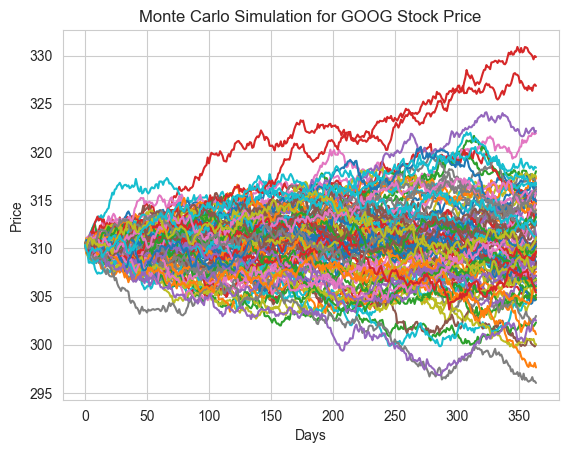

In [ ]:
start_price = 310.332

for run in range(100):
    plt.plot(stock_monte_carlo(start_price,days,mu,sigma))

plt.xlabel('Days')
plt.ylabel('Price')
plt.title('Monte Carlo Simulation for Google Stock Price')

In [33]:
runs = 10000
simulations = np.zeros(runs)
for run in range(runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]

1% Quantile of final stock price after 365 days: $298.70


Text(0.5, 1.0, 'Final price distribution for Google Stock after 365 days')

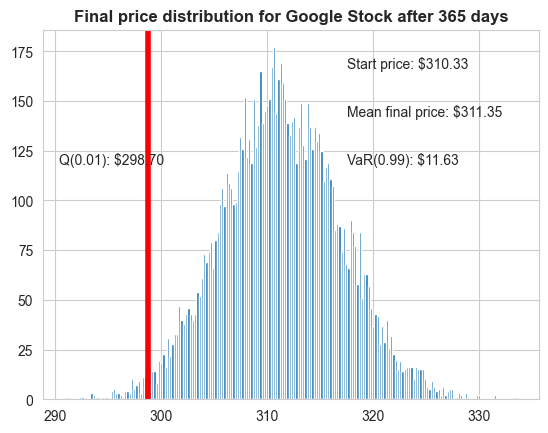

In [35]:
q = np.percentile(simulations, 1)
print(f"1% Quantile of final stock price after {days} days: ${q:.2f}")

plt.hist(simulations, bins=200)
plt.figtext(0.6, 0.8, f"Start price: ${start_price:.2f}")
plt.figtext(0.6, 0.7, f"Mean final price: ${simulations.mean():.2f}")
plt.figtext(0.6, 0.6, f"VaR(0.99): ${start_price - q:.2f}")
plt.figtext(0.15, 0.6, f"Q(0.01): ${q:.2f}")
plt.axvline(x=q, linewidth=4, color='r')

plt.title(f"Final price distribution for Google Stock after {days} days", weight='bold')